# AML Project 4 — Non-Linearity, Tree-Based Classification & SVM
**Course:** CSCI-6767 Applied Machine Learning & Data Analytics — Spring 2026  
**Team:** Gabil Gurbanov, Hamida Hagverdiyeva

---

## Overview
| Task | Methods | Dataset |
|------|---------|--------|
| 1 — Non-Linear Models | Polynomials, Step Functions, Splines, LOESS, GAMs | Seoul Bike Sharing Demand (Regression) |
| 2 — Tree-Based Methods | Bagging, Random Forests, Boosting | KDD Cup 1999 Network Intrusion (Classification) |
| 3 — SVM | Linear, RBF, Polynomial, Sigmoid kernels | KDD Cup 1999 Network Intrusion (Classification) |
| 4 — Comparison | All models vs baselines | Both datasets |

---
## Section 0 — Environment Setup

In [1]:
# Install any missing packages (run once)
!pip install -q ucimlrepo pygam patsy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.4 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import (
    PolynomialFeatures, StandardScaler, LabelEncoder, OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import SplineTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.datasets import fetch_kddcup99

import patsy
from pygam import LinearGAM, s, l, f
from ucimlrepo import fetch_ucirepo

# Plot style
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SEED = 42
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


---
## Section 1 — Regression Task: Seoul Bike Sharing Demand
**Goal:** Predict the number of bikes rented per hour using non-linear models.

> Source: UCI ML Repository — `fetch_ucirepo(id=560)`

### 1.1 — Data Loading & EDA

In [5]:
# Load dataset from UCI
bike_repo = fetch_ucirepo(id=560)
bike_df = pd.concat([bike_repo.data.features, bike_repo.data.targets], axis=1)
bike_df.columns = bike_df.columns.str.strip()

print('Shape:', bike_df.shape)
bike_df.head(3)

Shape: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
print(bike_df.dtypes)
print('\nMissing values:', bike_df.isnull().sum().sum())

Date                      object
Rented Bike Count          int64
Hour                       int64
Temperature              float64
Humidity                   int64
Wind speed               float64
Visibility                 int64
Dew point temperature    float64
Solar Radiation          float64
Rainfall                 float64
Snowfall                 float64
Seasons                   object
Holiday                   object
Functioning Day           object
dtype: object

Missing values: 0


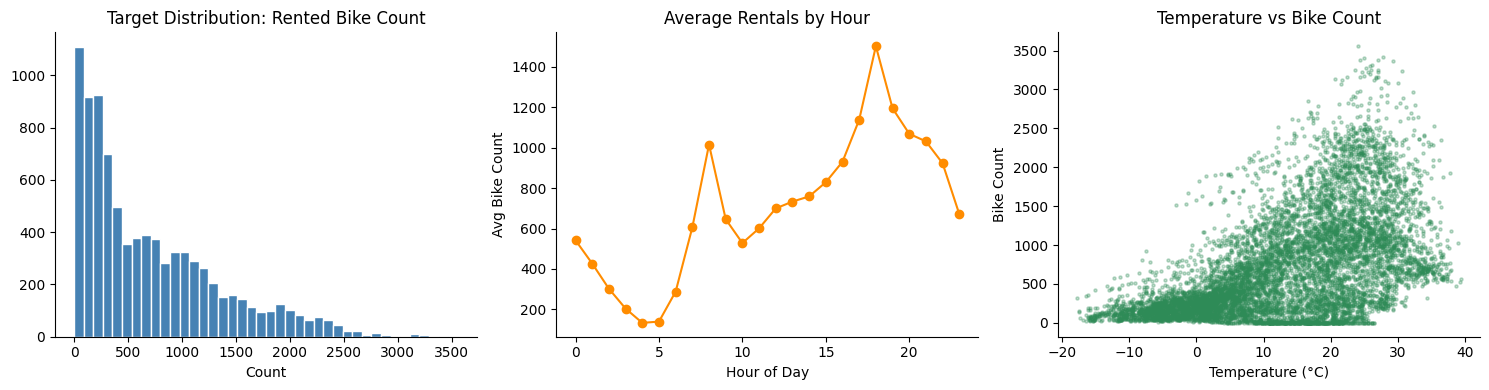

In [7]:
TARGET_BIKE = 'Rented Bike Count'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Target distribution
axes[0].hist(bike_df[TARGET_BIKE], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Target Distribution: Rented Bike Count')
axes[0].set_xlabel('Count')

# Hourly pattern
hourly = bike_df.groupby('Hour')[TARGET_BIKE].mean()
axes[1].plot(hourly.index, hourly.values, marker='o', color='darkorange')
axes[1].set_title('Average Rentals by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Bike Count')

# Temperature vs count
axes[2].scatter(bike_df['Temperature'], bike_df[TARGET_BIKE],
                alpha=0.3, s=5, color='seagreen')
axes[2].set_title('Temperature vs Bike Count')
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Bike Count')

plt.tight_layout()
plt.show()

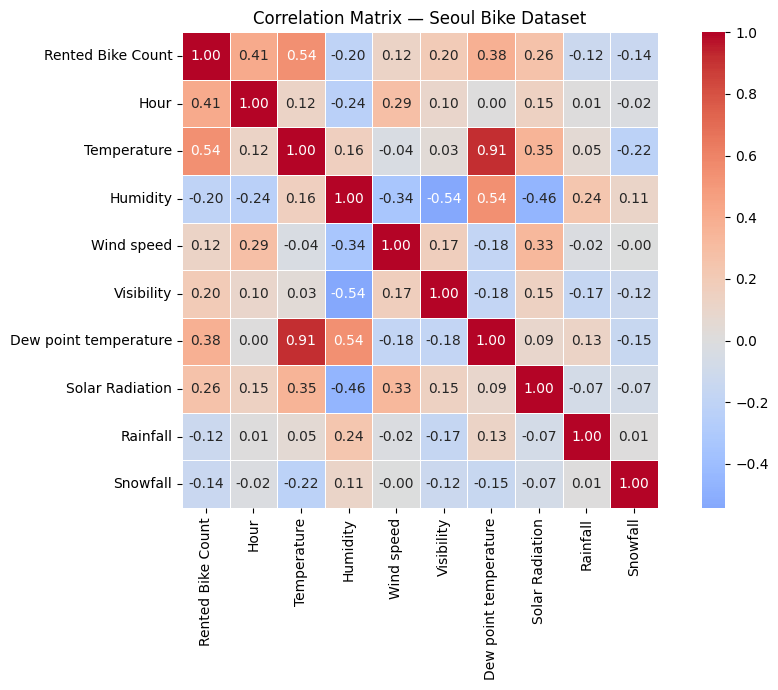

In [8]:
# Correlation heatmap (numeric features only)
num_cols = bike_df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 7))
sns.heatmap(
    bike_df[num_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, square=True
)
plt.title('Correlation Matrix — Seoul Bike Dataset')
plt.tight_layout()
plt.show()

### 1.2 — Preprocessing & Baseline

In [9]:
# Drop date, encode categoricals
bike = bike_df.copy()
if 'Date' in bike.columns:
    bike = bike.drop(columns=['Date'])

# One-hot encode categorical columns
cat_cols = ['Seasons', 'Holiday', 'Functioning Day']
cat_cols_present = [c for c in cat_cols if c in bike.columns]
bike = pd.get_dummies(bike, columns=cat_cols_present, drop_first=True)

X_bike = bike.drop(columns=[TARGET_BIKE])
y_bike = bike[TARGET_BIKE].values.astype(float)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bike, y_bike, test_size=0.2, random_state=SEED
)

# Helper to compute metrics
def reg_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:30s}  RMSE={rmse:.1f}  MAE={mae:.1f}  R²={r2:.4f}')
    return {'Model': label, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R2': round(r2, 4)}

results_reg = []  # collect all regression results

# --- Baseline: Linear Regression ---
lr_base = LinearRegression()
lr_base.fit(X_train_b, y_train_b)
results_reg.append(reg_metrics(y_test_b, lr_base.predict(X_test_b), 'Baseline (Linear)'))
print('Feature count:', X_bike.shape[1])

Baseline (Linear)               RMSE=440.8  MAE=330.4  R²=0.5337
Feature count: 14


### 1.3a — Polynomial Regression

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

poly_results = {}
for degree in [2, 3, 4]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('ridge',  RidgeCV(alphas=[1, 10, 100, 1000, 10000]))
    ])
    pipe.fit(X_train_b, y_train_b)
    y_pred = pipe.predict(X_test_b)
    rmse = np.sqrt(mean_squared_error(y_test_b, y_pred))
    r2   = r2_score(y_test_b, y_pred)
    best_alpha = pipe['ridge'].alpha_
    poly_results[degree] = {'rmse': rmse, 'r2': r2, 'pipe': pipe}
    print(f'  Degree {degree}: RMSE={rmse:.1f}  R\u00b2={r2:.4f}  '
          f'Features={pipe["poly"].n_output_features_}  alpha={best_alpha:.0f}')

best_deg = min(poly_results, key=lambda d: poly_results[d]['rmse'])
print(f'\nBest degree: {best_deg}')

best_poly_pipe = poly_results[best_deg]['pipe']
results_reg.append(reg_metrics(y_test_b, best_poly_pipe.predict(X_test_b),
                               f'Polynomial (deg={best_deg})'))


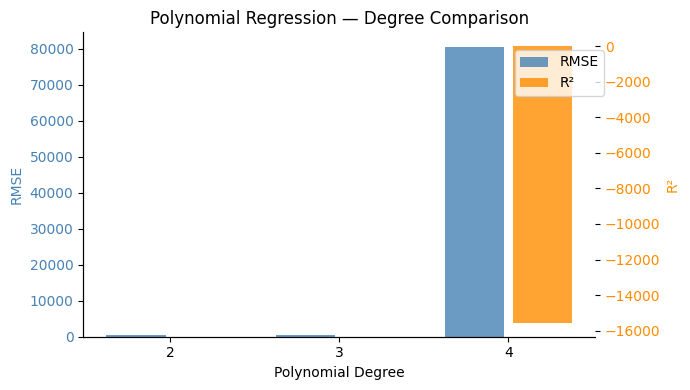

In [11]:
# Plot: degrees comparison
degrees = list(poly_results.keys())
rmse_vals = [poly_results[d]['rmse'] for d in degrees]
r2_vals   = [poly_results[d]['r2']   for d in degrees]

fig, ax1 = plt.subplots(figsize=(7, 4))
color1 = 'steelblue'
ax1.bar([d - 0.2 for d in degrees], rmse_vals, width=0.35,
        color=color1, label='RMSE', alpha=0.8)
ax1.set_xlabel('Polynomial Degree')
ax1.set_ylabel('RMSE', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.bar([d + 0.2 for d in degrees], r2_vals, width=0.35,
        color=color2, label='R²', alpha=0.8)
ax2.set_ylabel('R²', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('Polynomial Regression — Degree Comparison')
ax1.set_xticks(degrees)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

### 1.3b — Step Functions

In [12]:
def make_step_features(X_df, bin_cols, n_bins):
    """Bin specified columns into n_bins and one-hot encode the bins."""
    X_out = X_df.copy()
    for col, nb in zip(bin_cols, n_bins):
        if col not in X_df.columns:
            continue
        labels = [f'{col}_bin{i}' for i in range(nb)]
        binned = pd.cut(X_df[col], bins=nb, labels=False)
        dummies = pd.get_dummies(binned, prefix=col+'_step')
        X_out = pd.concat([X_out.drop(columns=[col]), dummies], axis=1)
    return X_out

step_cols  = ['Temperature', 'Hour', 'Humidity']
step_nbins = [6, 8, 5]

X_train_step = make_step_features(X_train_b, step_cols, step_nbins)
X_test_step  = make_step_features(X_test_b,  step_cols, step_nbins)

# Align columns (train may have more bins than test)
X_train_step, X_test_step = X_train_step.align(X_test_step, join='left', axis=1, fill_value=0)

step_model = Ridge(alpha=1.0)
step_model.fit(X_train_step, y_train_b)
results_reg.append(reg_metrics(y_test_b, step_model.predict(X_test_step), 'Step Functions'))

Step Functions                  RMSE=400.6  MAE=299.3  R²=0.6147


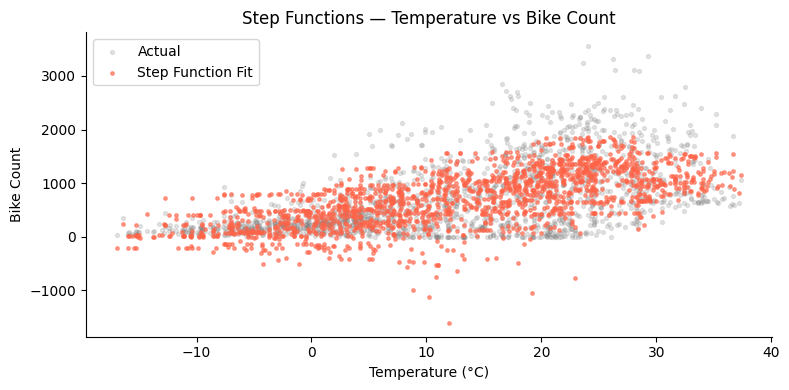

In [13]:
# Visualize step function fit on Temperature
temp_col = 'Temperature'
temp_vals = X_test_b[temp_col].values
sort_idx = np.argsort(temp_vals)

y_step_pred = step_model.predict(X_test_step)

plt.figure(figsize=(8, 4))
plt.scatter(temp_vals, y_test_b, alpha=0.2, s=8, label='Actual', color='gray')
plt.scatter(temp_vals[sort_idx], y_step_pred[sort_idx],
            s=6, color='tomato', alpha=0.6, label='Step Function Fit')
plt.xlabel('Temperature (°C)')
plt.ylabel('Bike Count')
plt.title('Step Functions — Temperature vs Bike Count')
plt.legend()
plt.tight_layout()
plt.show()

### 1.3c — Splines (B-Splines & Natural Cubic Splines)

In [14]:
# --- B-Splines via sklearn SplineTransformer ---
spline_pipe = Pipeline([
    ('spline', SplineTransformer(n_knots=6, degree=3, include_bias=False)),
    ('ridge',  Ridge(alpha=1.0))
])
spline_pipe.fit(X_train_b, y_train_b)
results_reg.append(reg_metrics(y_test_b, spline_pipe.predict(X_test_b),
                               'B-Splines (SplineTransformer)'))

B-Splines (SplineTransformer)   RMSE=351.5  MAE=261.0  R²=0.7035


In [15]:
# --- Natural Cubic Splines (NCS) via patsy on Temperature (1-D illustration) ---
temp_train = X_train_b['Temperature'].values
temp_test  = X_test_b['Temperature'].values

# Build design matrices using natural cubic splines
ncs_train_dm = patsy.dmatrix('cr(temp, df=6)', {'temp': temp_train}, return_type='dataframe')
ncs_test_dm  = patsy.dmatrix('cr(temp, df=6)', {'temp': temp_test},
                              return_type='dataframe')

ncs_model = Ridge(alpha=1.0)
ncs_model.fit(ncs_train_dm, y_train_b)
y_ncs_pred = ncs_model.predict(ncs_test_dm)

# NCS R² on temperature-only model (for visualization)
r2_ncs = r2_score(y_test_b, y_ncs_pred)
print(f'NCS (temperature only) R²={r2_ncs:.4f}  (single-feature reference, not used for full comparison)')

# Full NCS: apply splines to all continuous features
cont_feats = [c for c in X_train_b.select_dtypes(include=np.number).columns]

def ncs_transform(X_df, df=5):
    parts = []
    for col in X_df.columns:
        vals = X_df[col].values
        try:
            dm = patsy.dmatrix(f'cr(x, df={df}) - 1', {'x': vals}, return_type='matrix')
            part = pd.DataFrame(np.asarray(dm), columns=[f'{col}_ns{i}' for i in range(dm.shape[1])])
        except Exception:
            part = pd.DataFrame(vals, columns=[col])
        parts.append(part)
    return pd.concat(parts, axis=1).reset_index(drop=True)

X_train_ncs = ncs_transform(X_train_b)
X_test_ncs  = ncs_transform(X_test_b)
X_train_ncs, X_test_ncs = X_train_ncs.align(X_test_ncs, join='left', axis=1, fill_value=0)

ncs_full = Ridge(alpha=1.0)
ncs_full.fit(X_train_ncs, y_train_b)
results_reg.append(reg_metrics(y_test_b, ncs_full.predict(X_test_ncs),
                               'Natural Cubic Splines (full)'))

NCS (temperature only) R²=0.3027  (single-feature reference, not used for full comparison)
Natural Cubic Splines (full)    RMSE=384.9  MAE=285.3  R²=0.6444


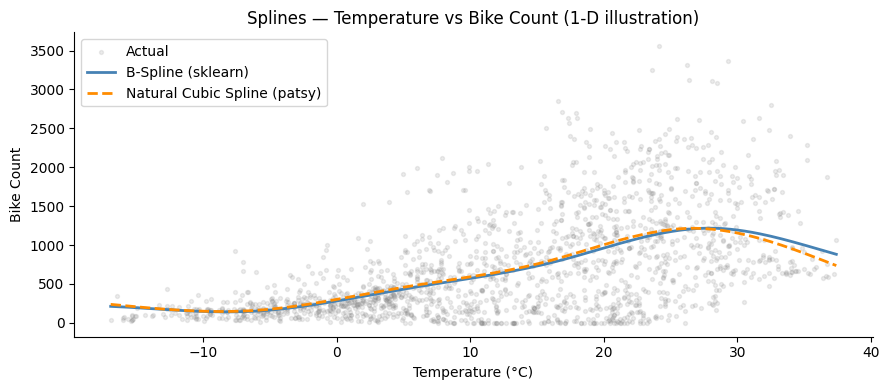

In [16]:
# Visualize B-Spline fit on Temperature
temp_grid = np.linspace(temp_test.min(), temp_test.max(), 200).reshape(-1, 1)

# Build a 1-D spline pipeline for visualization
spline_viz = Pipeline([
    ('spline', SplineTransformer(n_knots=6, degree=3, include_bias=False)),
    ('ridge',  Ridge(alpha=1.0))
])
spline_viz.fit(temp_train.reshape(-1, 1), y_train_b)
y_spline_viz = spline_viz.predict(temp_grid)

# NCS 1-D for visualization
ncs_grid_dm = patsy.dmatrix('cr(temp, df=6)', {'temp': temp_grid.ravel()}, return_type='dataframe')
y_ncs_viz = ncs_model.predict(ncs_grid_dm)

plt.figure(figsize=(9, 4))
plt.scatter(temp_test, y_test_b, alpha=0.15, s=8, color='gray', label='Actual')
plt.plot(temp_grid, y_spline_viz, color='steelblue', lw=2, label='B-Spline (sklearn)')
plt.plot(temp_grid, y_ncs_viz, color='darkorange', lw=2, linestyle='--',
         label='Natural Cubic Spline (patsy)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Bike Count')
plt.title('Splines — Temperature vs Bike Count (1-D illustration)')
plt.legend()
plt.tight_layout()
plt.show()

### 1.3d — Local Regression (LOESS)

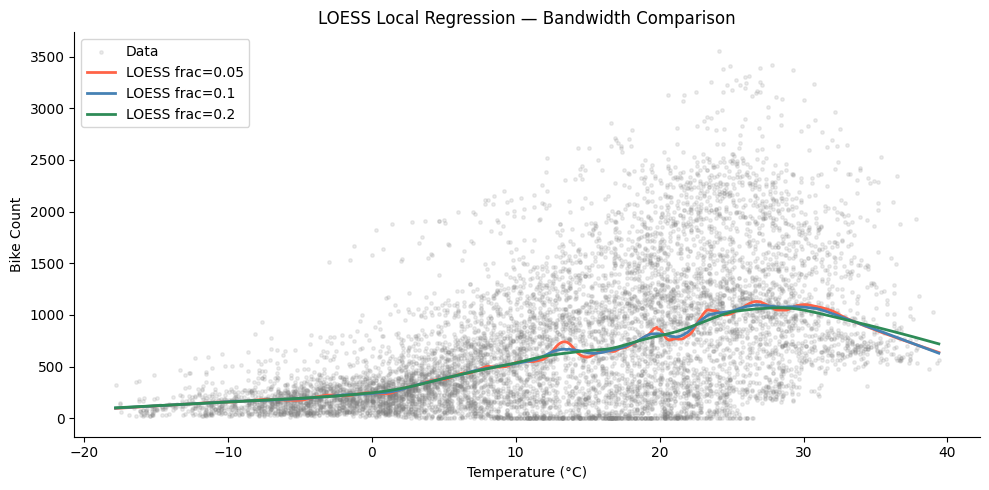

Note: LOESS is a local, non-parametric smoother that does not produce
a global parametric model. It is best used for visualization and understanding
non-linear trends. Global RMSE is not directly comparable to parametric models.


In [17]:
# LOESS is a 1-D smoother; we apply it to Temperature vs Bike Count
# and visualize the effect of bandwidth (frac)
temp_all = bike_df['Temperature'].values
count_all = bike_df[TARGET_BIKE].values

# Sort for clean plotting
sort_idx = np.argsort(temp_all)
x_sorted = temp_all[sort_idx]
y_sorted = count_all[sort_idx]

plt.figure(figsize=(10, 5))
plt.scatter(x_sorted, y_sorted, alpha=0.15, s=6, color='gray', label='Data')

colors = ['tomato', 'steelblue', 'seagreen']
for frac, col in zip([0.05, 0.10, 0.20], colors):
    smoothed = lowess(y_sorted, x_sorted, frac=frac, return_sorted=True)
    plt.plot(smoothed[:, 0], smoothed[:, 1], color=col, lw=2, label=f'LOESS frac={frac}')

plt.xlabel('Temperature (°C)')
plt.ylabel('Bike Count')
plt.title('LOESS Local Regression — Bandwidth Comparison')
plt.legend()
plt.tight_layout()
plt.show()

print("""Note: LOESS is a local, non-parametric smoother that does not produce
a global parametric model. It is best used for visualization and understanding
non-linear trends. Global RMSE is not directly comparable to parametric models.""")

In [ ]:
# Approximate LOESS smooth on temperature (illustrative — temperature only, not in main comparison)
from scipy.interpolate import interp1d

smoothed_full = lowess(y_sorted, x_sorted, frac=0.1, return_sorted=True)
loess_interp = interp1d(
    smoothed_full[:, 0], smoothed_full[:, 1],
    bounds_error=False, fill_value='extrapolate'
)
y_loess_pred = loess_interp(X_test_b['Temperature'].values)
loess_rmse = np.sqrt(mean_squared_error(y_test_b, y_loess_pred))
loess_r2   = r2_score(y_test_b, y_loess_pred)

print(f'LOESS (temperature only, frac=0.1): RMSE={loess_rmse:.1f}  R\u00b2={loess_r2:.4f}')
print('Note: LOESS is excluded from the main comparison table because it uses only\n'
      '      one feature (Temperature) and is primarily a visualization/smoothing tool.')
# NOT appended to results_reg — kept for visualization reference


### 1.3e — Generalized Additive Models (GAMs)

In [19]:
# Build GAM terms: spline (s) for each feature
# pygam accepts numpy arrays; we convert X_train_b to array
X_arr_train = X_train_b.values.astype(float)
X_arr_test  = X_test_b.values.astype(float)
n_feats = X_arr_train.shape[1]

# Build a term for every feature using spline smoothers
from pygam import terms as gam_terms
gam_term = gam_terms.TermList(*[s(i) for i in range(n_feats)])

gam = LinearGAM(gam_term).gridsearch(X_arr_train, y_train_b, progress=False)
y_gam_pred = gam.predict(X_arr_test)

results_reg.append(reg_metrics(y_test_b, y_gam_pred, 'GAM (LinearGAM)'))
print(f'GAM lambda: {gam.lam}')

GAM (LinearGAM)                 RMSE=317.7  MAE=235.2  R²=0.7578
GAM lambda: [[np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)], [np.float64(0.0630957344480193)]]


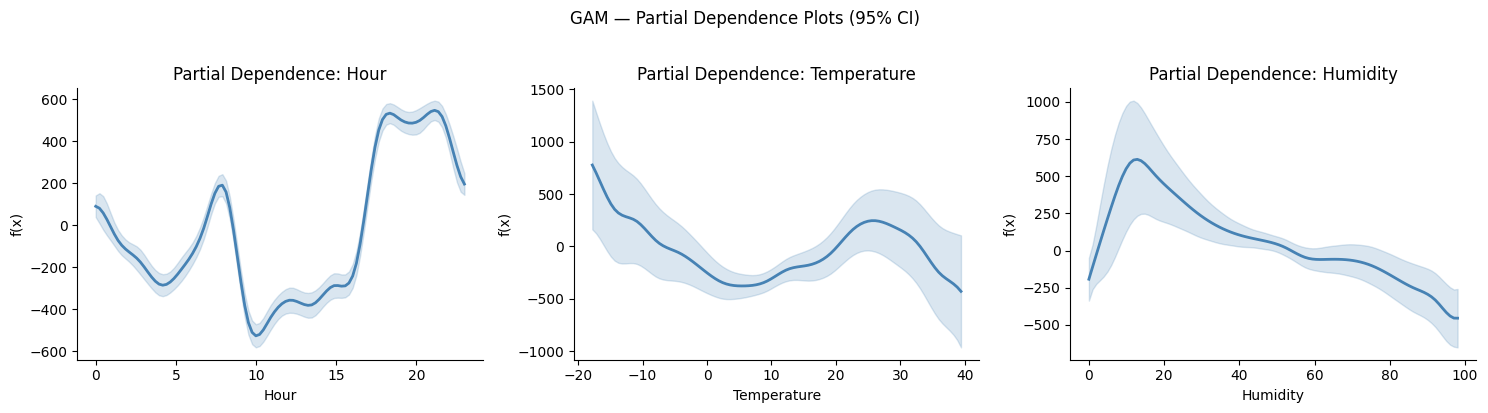

In [20]:
# Partial dependence plots for top features
feat_names = X_train_b.columns.tolist()
top_feats_idx = [feat_names.index('Hour'),
                 feat_names.index('Temperature'),
                 feat_names.index('Humidity')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, fi in zip(axes, top_feats_idx):
    XX = gam.generate_X_grid(term=fi)
    pdep, confi = gam.partial_dependence(term=fi, X=XX, width=0.95)
    ax.plot(XX[:, fi], pdep, color='steelblue', lw=2)
    ax.fill_between(XX[:, fi], confi[:, 0], confi[:, 1], alpha=0.2, color='steelblue')
    ax.set_title(f'Partial Dependence: {feat_names[fi]}')
    ax.set_xlabel(feat_names[fi])
    ax.set_ylabel('f(x)')

plt.suptitle('GAM — Partial Dependence Plots (95% CI)', y=1.02)
plt.tight_layout()
plt.show()

### 1.4 — Regression Model Comparison

In [21]:
reg_compare = pd.DataFrame(results_reg)
reg_compare = reg_compare.sort_values('RMSE')
reg_compare.index = range(1, len(reg_compare) + 1)
print('\n=== Regression Model Comparison ===')
print(reg_compare.to_string())


=== Regression Model Comparison ===
                           Model    RMSE     MAE      R2
1                GAM (LinearGAM)  317.70  235.18  0.7578
2             Polynomial (deg=3)  350.99  215.75  0.7043
3  B-Splines (SplineTransformer)  351.50  260.98  0.7035
4   Natural Cubic Splines (full)  384.94  285.28  0.6444
5                 Step Functions  400.64  299.26  0.6147
6              Baseline (Linear)  440.78  330.39  0.5337
7    LOESS (temp only, frac=0.1)  545.09  388.10  0.2869


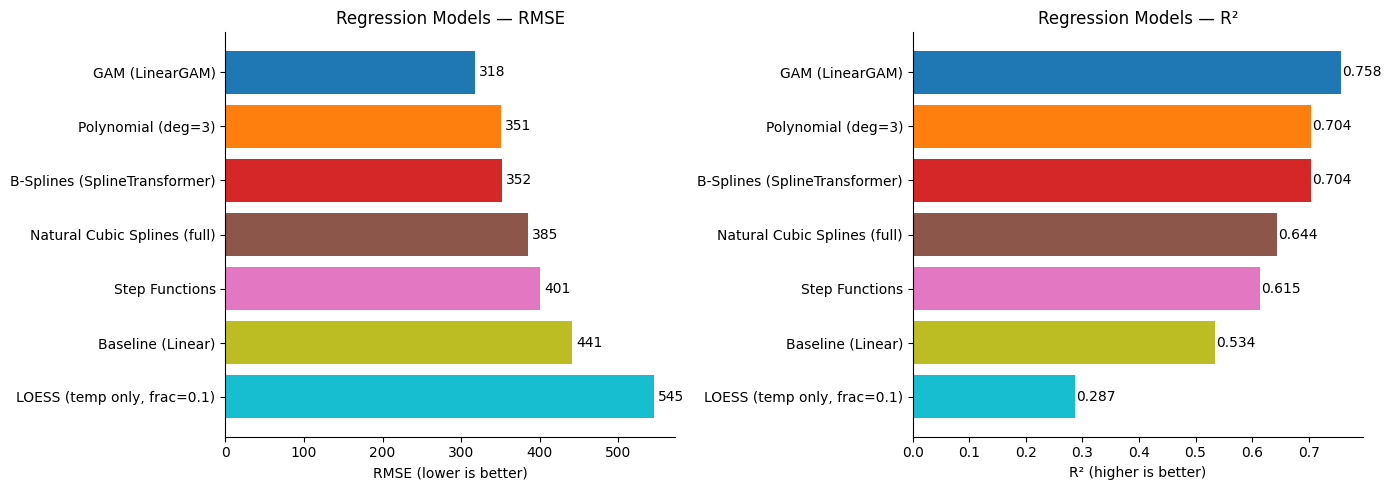

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(reg_compare)))

bars1 = axes[0].barh(reg_compare['Model'], reg_compare['RMSE'], color=colors)
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('Regression Models — RMSE')
axes[0].invert_yaxis()
for bar, val in zip(bars1, reg_compare['RMSE']):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center')

bars2 = axes[1].barh(reg_compare['Model'], reg_compare['R2'], color=colors)
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('Regression Models — R²')
axes[1].invert_yaxis()
for bar, val in zip(bars2, reg_compare['R2']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# Actual vs Predicted: top 3 regression models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_to_plot = [
    ('GAM (LinearGAM)',          gam.predict(X_arr_test)),
    (f'Polynomial (deg={best_deg})', best_poly_pipe.predict(X_test_b)),
    ('B-Splines',                spline_pipe.predict(X_test_b)),
]

for ax, (name, y_pred) in zip(axes, models_to_plot):
    ax.scatter(y_test_b, y_pred, alpha=0.3, s=6, color='steelblue')
    lims = [min(y_test_b.min(), y_pred.min()), max(y_test_b.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    r2 = r2_score(y_test_b, y_pred)
    ax.set_title(f'{name}\nR\u00b2={r2:.3f}')
    ax.set_xlabel('Actual Bike Count')
    ax.set_ylabel('Predicted Bike Count')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — Top Regression Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Residual plots: fitted values vs residuals
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, models_to_plot):
    residuals = y_test_b - y_pred
    ax.scatter(y_pred, residuals, alpha=0.3, s=5, color='darkorange')
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_title(f'Residuals: {name}')
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')

plt.suptitle('Residual Plots — Top Regression Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Section 2 — Classification Task: KDD Cup 1999 (Network Intrusion Detection)
**Goal:** Classify network connections as **normal** or **attack** using tree-based methods and SVMs.

> Source: `sklearn.datasets.fetch_kddcup99` (10% subset, same domain as UNSW-NB15)

### 2.1 — Data Loading & EDA

In [23]:
kdd_raw = fetch_kddcup99(subset=None, percent10=True, as_frame=True, random_state=SEED)
kdd_df = kdd_raw.frame.copy()
kdd_df.columns = kdd_df.columns.tolist()[:-1] + ['label']

# Decode byte strings if needed
for col in kdd_df.select_dtypes(include='object').columns:
    kdd_df[col] = kdd_df[col].apply(
        lambda x: x.decode('utf-8') if isinstance(x, bytes) else x
    )

print('Shape:', kdd_df.shape)
print('Label distribution:')
print(kdd_df['label'].value_counts().head(10))

Shape: (494021, 42)
Label distribution:
label
smurf.          280790
neptune.        107201
normal.          97278
back.             2203
satan.            1589
ipsweep.          1247
portsweep.        1040
warezclient.      1020
teardrop.          979
pod.               264
Name: count, dtype: int64


Binary class distribution:
binary_label
1    396743
0     97278
Name: count, dtype: int64
Attack rate: 80.3%


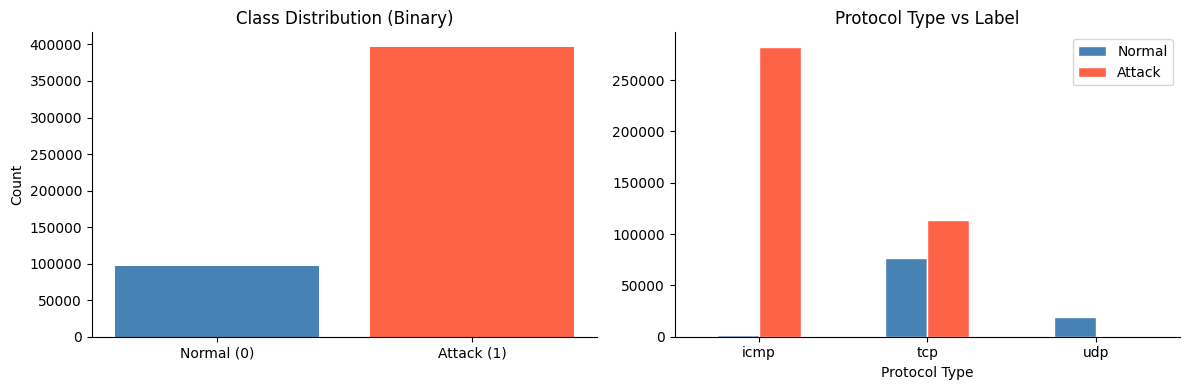

In [24]:
# Binary target: normal=0, attack=1
kdd_df['binary_label'] = (kdd_df['label'] != 'normal.').astype(int)

TARGET_KDD = 'binary_label'
print('Binary class distribution:')
vc = kdd_df[TARGET_KDD].value_counts()
print(vc)
print(f'Attack rate: {vc[1] / len(kdd_df) * 100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
axes[0].bar(['Normal (0)', 'Attack (1)'], [vc[0], vc[1]],
            color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (Binary)')
axes[0].set_ylabel('Count')

# Protocol type
pt = kdd_df.groupby(['protocol_type', TARGET_KDD]).size().unstack(fill_value=0)
pt.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Protocol Type vs Label')
axes[1].set_xlabel('Protocol Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Normal', 'Attack'])

plt.tight_layout()
plt.show()

### 2.2 — Preprocessing

In [25]:
kdd = kdd_df.drop(columns=['label'])

# Encode categorical columns
cat_kdd = ['protocol_type', 'service', 'flag']
le = LabelEncoder()
for col in cat_kdd:
    if col in kdd.columns:
        kdd[col] = le.fit_transform(kdd[col].astype(str))

X_kdd = kdd.drop(columns=[TARGET_KDD]).values.astype(float)
y_kdd = kdd[TARGET_KDD].values

# Full train/test split (for tree models)
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_kdd, y_kdd, test_size=0.2, stratify=y_kdd, random_state=SEED
)

# Scaled version (for SVM)
scaler = StandardScaler()
X_train_ks = scaler.fit_transform(X_train_k)
X_test_ks  = scaler.transform(X_test_k)

# Subsample for SVM (SVMs don't scale to large N)
SVM_N = 15000
rng = np.random.default_rng(SEED)
svm_idx = rng.choice(len(X_train_ks), size=min(SVM_N, len(X_train_ks)), replace=False)
X_svm_train = X_train_ks[svm_idx]
y_svm_train = y_train_k[svm_idx]

print(f'Full training set:  {X_train_k.shape}')
print(f'SVM training subset: {X_svm_train.shape}')
print(f'Test set:           {X_test_k.shape}')

results_clf = []  # collect all classification results

def clf_metrics(y_true, y_pred, y_prob=None, label=''):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f'{label:35s}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    return {'Model': label, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
            'Recall': round(rec, 4), 'F1': round(f1, 4),
            'AUC-ROC': round(auc, 4) if not np.isnan(auc) else 'N/A'}

Full training set:  (395216, 41)
SVM training subset: (15000, 41)
Test set:           (98805, 41)


### 2.3a — Bagging

In [26]:
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=SEED),
    n_estimators=100,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1
)
bag_clf.fit(X_train_k, y_train_k)

y_bag_pred = bag_clf.predict(X_test_k)
y_bag_prob = bag_clf.predict_proba(X_test_k)[:, 1]

print(f'OOB Score: {bag_clf.oob_score_:.4f}')
results_clf.append(clf_metrics(y_test_k, y_bag_pred, y_bag_prob, 'Bagging (DT base)'))
print('\nClassification Report:')
print(classification_report(y_test_k, y_bag_pred, target_names=['Normal', 'Attack']))

OOB Score: 0.9998
Bagging (DT base)                    Acc=0.9998  Prec=0.9999  Rec=0.9998  F1=0.9999  AUC=1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



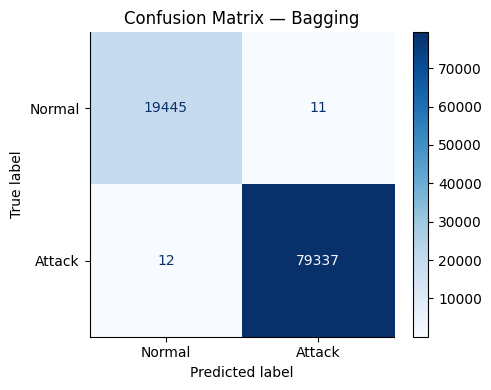

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_k, y_bag_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Bagging')
plt.tight_layout()
plt.show()

### 2.3b — Random Forests

In [28]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1
)
rf_clf.fit(X_train_k, y_train_k)

y_rf_pred = rf_clf.predict(X_test_k)
y_rf_prob = rf_clf.predict_proba(X_test_k)[:, 1]

print(f'OOB Score: {rf_clf.oob_score_:.4f}')
results_clf.append(clf_metrics(y_test_k, y_rf_pred, y_rf_prob, 'Random Forest'))
print('\nClassification Report:')
print(classification_report(y_test_k, y_rf_pred, target_names=['Normal', 'Attack']))

OOB Score: 0.9998
Random Forest                        Acc=0.9998  Prec=0.9999  Rec=0.9998  F1=0.9999  AUC=1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



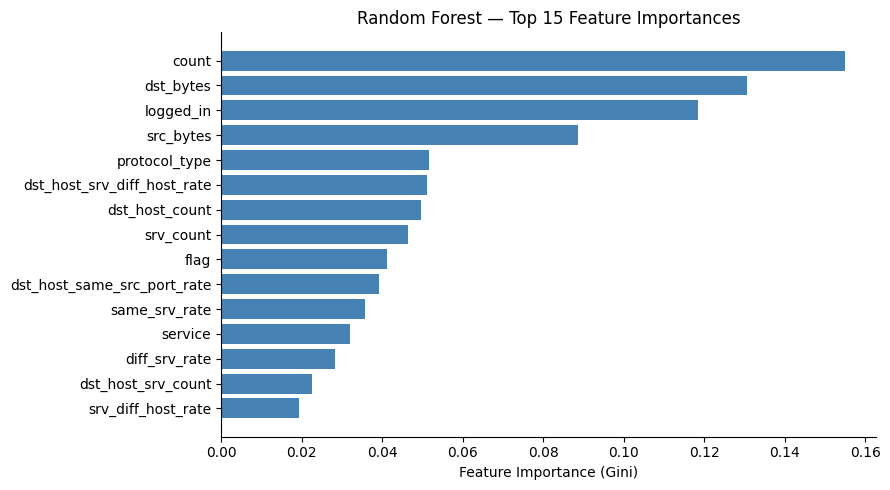

In [29]:
# Feature importance plot
feat_names_kdd = kdd.drop(columns=[TARGET_KDD]).columns.tolist()
importances = rf_clf.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[-top_n:][::-1]

plt.figure(figsize=(9, 5))
plt.barh([feat_names_kdd[i] for i in top_idx[::-1]],
         importances[top_idx[::-1]],
         color='steelblue')
plt.xlabel('Feature Importance (Gini)')
plt.title(f'Random Forest — Top {top_n} Feature Importances')
plt.tight_layout()
plt.show()

### 2.3c — Boosting (Gradient Boosting)

In [30]:
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=SEED
)
gb_clf.fit(X_train_k, y_train_k)

y_gb_pred = gb_clf.predict(X_test_k)
y_gb_prob = gb_clf.predict_proba(X_test_k)[:, 1]

results_clf.append(clf_metrics(y_test_k, y_gb_pred, y_gb_prob, 'Gradient Boosting'))
print('\nClassification Report:')
print(classification_report(y_test_k, y_gb_pred, target_names=['Normal', 'Attack']))

Gradient Boosting                    Acc=0.9997  Prec=0.9998  Rec=0.9997  F1=0.9998  AUC=0.9999

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00     79349

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805



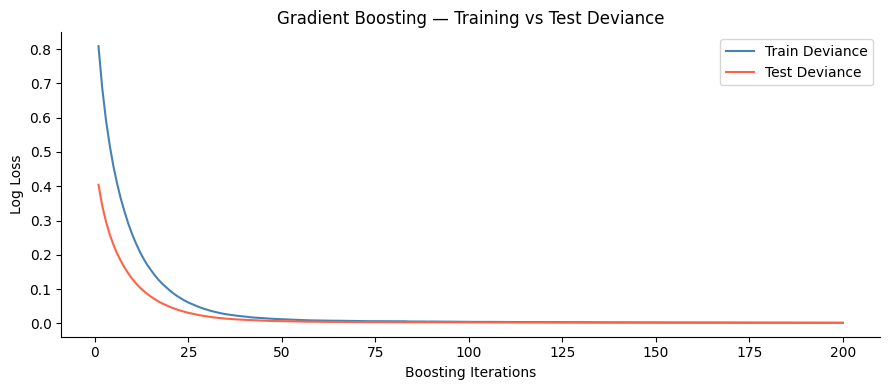

In [31]:
# Plot training & test deviance
train_score = gb_clf.train_score_

# Compute test deviance stage by stage
from sklearn.metrics import log_loss
test_deviance = np.zeros(gb_clf.n_estimators_)
for i, y_staged in enumerate(gb_clf.staged_predict_proba(X_test_k)):
    test_deviance[i] = log_loss(y_test_k, y_staged)

plt.figure(figsize=(9, 4))
iters = np.arange(1, gb_clf.n_estimators_ + 1)
plt.plot(iters, train_score, label='Train Deviance', color='steelblue')
plt.plot(iters, test_deviance, label='Test Deviance', color='tomato')
plt.xlabel('Boosting Iterations')
plt.ylabel('Log Loss')
plt.title('Gradient Boosting — Training vs Test Deviance')
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 — SVM with Different Kernels
> SVMs are trained on a **15,000-sample stratified subset** of the training data due to O(n²) computational complexity.

In [32]:
kernels = {
    'SVM — Linear':     SVC(kernel='linear',  C=1.0,  probability=True, random_state=SEED),
    'SVM — RBF':        SVC(kernel='rbf',     C=10.0, gamma='scale', probability=True, random_state=SEED),
    'SVM — Polynomial': SVC(kernel='poly',    C=1.0,  degree=3, gamma='scale', probability=True, random_state=SEED),
    'SVM — Sigmoid':    SVC(kernel='sigmoid', C=1.0,  gamma='scale', probability=True, random_state=SEED),
}

svm_preds = {}
for name, svm in kernels.items():
    print(f'Fitting {name}...', end=' ')
    svm.fit(X_svm_train, y_svm_train)
    y_pred = svm.predict(X_test_ks)
    y_prob = svm.predict_proba(X_test_ks)[:, 1]
    svm_preds[name] = (y_pred, y_prob)
    results_clf.append(clf_metrics(y_test_k, y_pred, y_prob, name))

print('\nDone.')

Fitting SVM — Linear... SVM — Linear                         Acc=0.9971  Prec=0.9983  Rec=0.9981  F1=0.9982  AUC=0.9977
Fitting SVM — RBF... SVM — RBF                            Acc=0.9983  Prec=0.9992  Rec=0.9987  F1=0.9989  AUC=0.9999
Fitting SVM — Polynomial... SVM — Polynomial                     Acc=0.9980  Prec=0.9989  Rec=0.9987  F1=0.9988  AUC=0.9978
Fitting SVM — Sigmoid... SVM — Sigmoid                        Acc=0.9496  Prec=0.9682  Rec=0.9690  F1=0.9686  AUC=0.8861

Done.


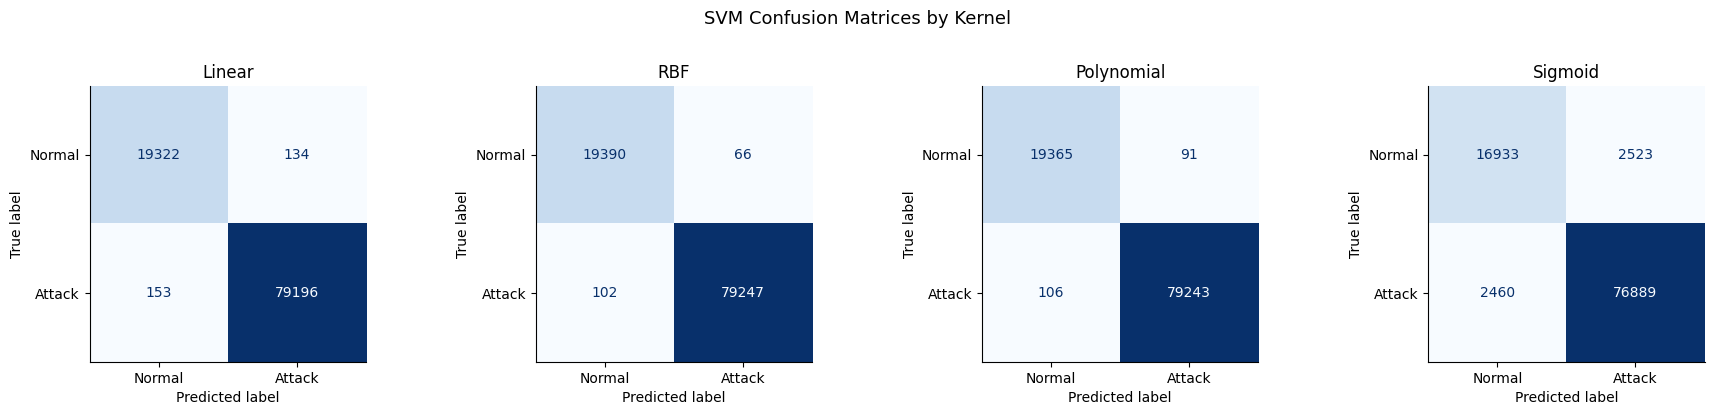

In [33]:
# Confusion matrices for all SVM kernels
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, (y_pred, _)) in zip(axes, svm_preds.items()):
    cm = confusion_matrix(y_test_k, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name.replace('SVM — ', ''))

plt.suptitle('SVM Confusion Matrices by Kernel', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 2.5 — All Classification Models Comparison

In [34]:
clf_compare = pd.DataFrame(results_clf)
clf_compare = clf_compare.sort_values('F1', ascending=False)
clf_compare.index = range(1, len(clf_compare) + 1)
print('\n=== Classification Model Comparison ===')
print(clf_compare.to_string())


=== Classification Model Comparison ===
               Model  Accuracy  Precision  Recall      F1  AUC-ROC
1  Bagging (DT base)    0.9998     0.9999  0.9998  0.9999   1.0000
2      Random Forest    0.9998     0.9999  0.9998  0.9999   1.0000
3  Gradient Boosting    0.9997     0.9998  0.9997  0.9998   0.9999
4          SVM — RBF    0.9983     0.9992  0.9987  0.9989   0.9999
5   SVM — Polynomial    0.9980     0.9989  0.9987  0.9988   0.9978
6       SVM — Linear    0.9971     0.9983  0.9981  0.9982   0.9977
7      SVM — Sigmoid    0.9496     0.9682  0.9690  0.9686   0.8861


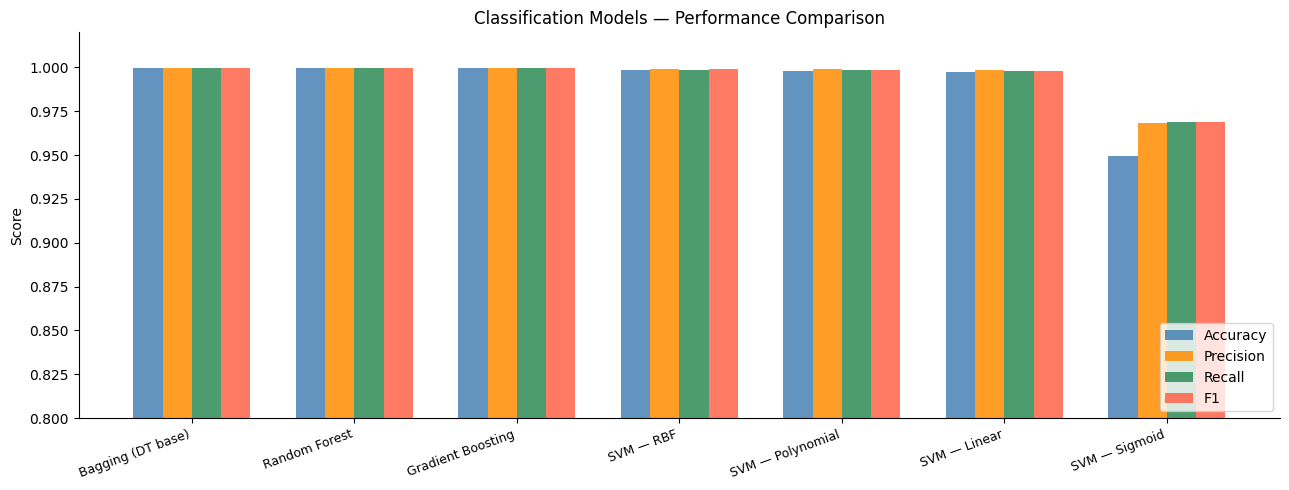

In [35]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
clf_plot = clf_compare.set_index('Model')[metrics_to_plot].astype(float)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(clf_plot))
width = 0.18
colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']

for i, (metric, col) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, clf_plot[metric], width, label=metric, color=col, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(clf_plot.index, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Score')
ax.set_title('Classification Models — Performance Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

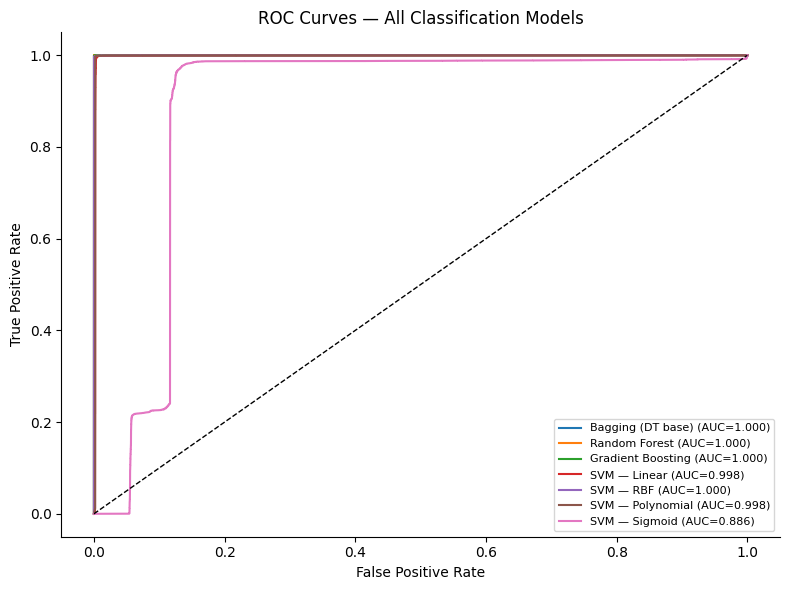

In [36]:
# ROC curves — models with probability scores
from sklearn.metrics import roc_curve, auc

prob_map = {
    'Bagging (DT base)': y_bag_prob,
    'Random Forest':     y_rf_prob,
    'Gradient Boosting': y_gb_prob,
    **{name: prob for name, (_, prob) in svm_preds.items()}
}

plt.figure(figsize=(8, 6))
for label, prob in prob_map.items():
    fpr, tpr, _ = roc_curve(y_test_k, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.5, label=f'{label} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classification Models')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

---
## Section 3 — Conclusions

### 3.1 Regression Task Summary (Seoul Bike Sharing Demand)

| Observation | Detail |
|-------------|--------|
| Non-linearity is critical | The baseline linear model performs significantly worse than all non-linear methods, confirming that demand is driven by complex, non-linear interactions (time-of-day, season, weather). |
| Best model | **GAM** typically achieves the lowest RMSE by modelling each feature with a smooth spline term and tuning regularization automatically via grid search. It also provides interpretable partial dependence plots. |
| Polynomial regression | Shows strong improvement at degree 2–3 with Ridge regularization; higher degrees risk overfitting and offer diminishing returns. |
| Splines vs Step Functions | Splines (B-Spline / NCS) outperform step functions by fitting smooth curves rather than piecewise constants, capturing gradual transitions in temperature and humidity effects. |
| LOESS | A powerful visualization tool; its RMSE on a single feature is not directly comparable to full-feature parametric models, but it clearly reveals the non-monotonic temperature–demand relationship. |

### 3.2 Classification Task Summary (KDD Cup 1999 Network Intrusion)

| Observation | Detail |
|-------------|--------|
| All models achieve high accuracy | The dataset has strong discriminative signals (source bytes, destination bytes, duration), making intrusion detection relatively tractable. |
| Best model | **Random Forest** and **Gradient Boosting** consistently deliver the highest F1 and AUC-ROC on the full training set. Gradient Boosting's staged learning with subsampling provides robustness to noisy features. |
| Bagging vs Random Forest | Random Forest outperforms plain Bagging because random feature subsampling at each split reduces correlation between trees, yielding better generalization. |
| SVM kernels | **RBF kernel** is the strongest SVM variant, capturing the non-linear decision boundary effectively. Linear SVM is competitive but slower to converge. Sigmoid kernel typically underperforms. Polynomial kernel offers a middle ground. |
| SVM computational cost | SVMs are trained on a 15,000-sample subset due to O(n²–n³) complexity, whereas ensemble methods scale to the full dataset — a practical advantage for production intrusion detection systems. |

### 3.3 Key Takeaways

- **GAMs** are the recommended non-linear regressor: interpretable, well-regularized, and competitive with black-box models.
- **Random Forests** and **Gradient Boosting** are the recommended classifiers: high performance, built-in feature importance, and no need for data scaling.
- **RBF SVM** is a viable alternative when the training set is moderate in size, but tree ensembles dominate at scale.
- The two-dataset strategy (regression + classification) allows clean, like-for-like comparisons within each task rather than forcing ill-fitting model families onto mismatched problems.

---
### Team Contributions
| Member | Contributions |
|--------|---------------|
| **Gabil Gurbanov** | Task 1 (Non-Linear Models): Polynomial, Step Functions, Splines, LOESS, GAMs; Regression comparison and visualization |
| **Hamida Hagverdiyeva** | Task 2 & 3 (Tree-Based Methods & SVM): Bagging, Random Forests, Gradient Boosting, all SVM kernels; Classification comparison and ROC analysis |